# Experiment: Training with Leaky Feature (Tax & Surcharge)

**Hypothesis**: If we include `Tax & Surcharge (BDT)` during training, the model will learn the strong signal between Tax and Total Fare (r=0.98). At prediction time, Tax isn't available — so we build a **two-stage pipeline**:

1. **Stage 1** — Predict `Tax & Surcharge` from features available at booking time
2. **Stage 2** — Predict `Total Fare` using real features + predicted Tax

**Evaluation**: Only uses columns available at prediction time:
`Class`, `Aircraft Type`, `Destination`, `Source`, `Duration (hrs)`, `Stopovers`, `Days Before Departure`, `Airline`, `Booking Source`, `Seasonality`, `Departure Date & Time`

In [1]:
# ── 1. Setup & Data Loading ──────────────────────────────────────────────────
from __future__ import annotations
import os, warnings
from pathlib import Path
from time import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import OrdinalEncoder

from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import lightgbm

from dotenv import find_dotenv, load_dotenv

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("viridis")
%matplotlib inline

# ── Load dataset ────────────────────────────────────────────────────────────
env_path = find_dotenv(".env.flight", usecwd=True)
if env_path:
    load_dotenv(env_path, override=False)

DATA_DIR = Path("data") / "kaggle" / "flight-price-dataset-of-bangladesh"
csv_path = next(DATA_DIR.rglob("*.csv"), None)

if csv_path is None:
    raise FileNotFoundError("Dataset CSV not found. Run the prototype notebook first to download it.")

df = pd.read_csv(csv_path)
print(f"Loaded: {csv_path}  shape={df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nTarget: Total Fare (BDT)  range=[{df['Total Fare (BDT)'].min():,.0f}, {df['Total Fare (BDT)'].max():,.0f}]")
print(f"Tax & Surcharge (BDT):     range=[{df['Tax & Surcharge (BDT)'].min():,.0f}, {df['Tax & Surcharge (BDT)'].max():,.0f}]")
print(f"Corr(Tax, Total): {df['Tax & Surcharge (BDT)'].corr(df['Total Fare (BDT)']):.4f}")

Loaded: data\kaggle\flight-price-dataset-of-bangladesh\Flight_Price_Dataset_of_Bangladesh.csv  shape=(57000, 17)

Columns: ['Airline', 'Source', 'Source Name', 'Destination', 'Destination Name', 'Departure Date & Time', 'Arrival Date & Time', 'Duration (hrs)', 'Stopovers', 'Aircraft Type', 'Class', 'Booking Source', 'Base Fare (BDT)', 'Tax & Surcharge (BDT)', 'Total Fare (BDT)', 'Seasonality', 'Days Before Departure']

Target: Total Fare (BDT)  range=[1,801, 558,987]
Tax & Surcharge (BDT):     range=[200, 73,383]
Corr(Tax, Total): 0.9822


## 2. Feature Engineering & Data Splitting

In [2]:
# ── 2. Feature Engineering ────────────────────────────────────────────────────

TARGET = 'Total Fare (BDT)'
TAX_COL = 'Tax & Surcharge (BDT)'
BASE_FARE_COL = 'Base Fare (BDT)'

# Features available at prediction/booking time (REAL features)
REAL_FEATURES = [
    'Airline', 'Source', 'Destination', 'Duration (hrs)', 'Stopovers',
    'Aircraft Type', 'Class', 'Booking Source', 'Seasonality',
    'Days Before Departure', 'Departure Date & Time'
]

# The leaky feature we're experimenting with
LEAKY_FEATURE = TAX_COL

REDUNDANT = ['Source Name', 'Destination Name', 'Arrival Date & Time']

def build_features(raw_df: pd.DataFrame, include_tax: bool = False) -> pd.DataFrame:
    """
    Build feature matrix from raw data.
    If include_tax=True, adds Tax & Surcharge as a feature (leaky experiment).
    """
    df = raw_df.copy()

    # ── Date features ──────────────────────────────────────────────────────
    dt = pd.to_datetime(df['Departure Date & Time'], errors='coerce')
    df['Month']       = dt.dt.month
    df['DayOfWeek']   = dt.dt.dayofweek
    df['Hour']        = dt.dt.hour
    df['Month_Sin']   = np.sin(2 * np.pi * df['Month'] / 12)
    df['Month_Cos']   = np.cos(2 * np.pi * df['Month'] / 12)
    df['Hour_Sin']    = np.sin(2 * np.pi * df['Hour']  / 24)
    df['Hour_Cos']    = np.cos(2 * np.pi * df['Hour']  / 24)
    df['Is_Weekend']  = (df['DayOfWeek'] >= 5).astype(int)
    df['Is_Peak']     = df['Month'].isin([1, 4, 5, 6, 12]).astype(int)

    # ── Interaction features ───────────────────────────────────────────────
    df['Route']         = df['Source'].astype(str) + '__' + df['Destination'].astype(str)
    df['Airline_Class'] = df['Airline'].astype(str) + '__' + df['Class'].astype(str)

    # ── Numeric transforms ─────────────────────────────────────────────────
    dur = df['Duration (hrs)'].clip(lower=0)
    df['Log_Duration']   = np.log1p(dur)
    df['Duration_Sq']    = dur ** 2
    dbd = df['Days Before Departure'].clip(lower=0)
    df['Log_DaysBefore'] = np.log1p(dbd)

    df['Booking_Window'] = pd.cut(
        dbd, bins=[-1, 3, 7, 14, 30, 60, 999],
        labels=['last_min', '3_7d', '1_2wk', '2_4wk', '1_2mo', '2mo_plus']
    ).astype(str)

    df['Haul_Type'] = pd.cut(
        dur, bins=[-1, 2, 5, 10, 999],
        labels=['short', 'medium', 'long', 'ultra_long']
    ).astype(str)

    df['Is_Direct'] = (df['Stopovers'] == 'Direct').astype(int)

    # Class-based interactions
    class_map = {'Economy': 1, 'Business': 2, 'First Class': 3}
    df['Class_Numeric']      = df['Class'].map(class_map).fillna(1)
    df['Duration_x_Class']   = dur * df['Class_Numeric']
    df['DaysBefore_x_Class'] = dbd * df['Class_Numeric']

    # ── Drop columns not needed ────────────────────────────────────────────
    drop_cols = ['Departure Date & Time', BASE_FARE_COL, TARGET] + REDUNDANT
    if not include_tax:
        drop_cols.append(TAX_COL)
    df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

    return df


# ── Build TWO versions of feature matrices ──────────────────────────────────
X_with_tax    = build_features(df, include_tax=True)    # FOR TRAINING (leaky)
X_without_tax = build_features(df, include_tax=False)   # FOR COMPARISON (clean)
y = df[TARGET]

# Define categorical columns
CAT_COLS = ['Airline', 'Source', 'Destination', 'Class', 'Stopovers',
            'Aircraft Type', 'Booking Source', 'Seasonality',
            'Route', 'Airline_Class', 'Booking_Window', 'Haul_Type']

NUM_COLS_CLEAN = [c for c in X_without_tax.columns if c not in CAT_COLS]
NUM_COLS_LEAKY = [c for c in X_with_tax.columns if c not in CAT_COLS]

print(f"Features WITHOUT Tax: {X_without_tax.shape[1]} ({len(CAT_COLS)} cat + {len(NUM_COLS_CLEAN)} num)")
print(f"Features WITH Tax:    {X_with_tax.shape[1]} ({len(CAT_COLS)} cat + {len(NUM_COLS_LEAKY)} num)")
print(f"\nExtra column in leaky version: {set(X_with_tax.columns) - set(X_without_tax.columns)}")

# ── Random 80/20 split ──────────────────────────────────────────────────────
np.random.seed(42)
idx = np.random.permutation(len(df))
n_train = int(0.8 * len(df))

train_idx, test_idx = idx[:n_train], idx[n_train:]

# WITH Tax (for leaky training)
X_train_tax = X_with_tax.iloc[train_idx]
X_test_tax  = X_with_tax.iloc[test_idx]

# WITHOUT Tax (clean — for baseline & evaluation)
X_train_clean = X_without_tax.iloc[train_idx]
X_test_clean  = X_without_tax.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

# Also extract raw Tax for stage-1 target
tax_train = df[TAX_COL].iloc[train_idx]
tax_test  = df[TAX_COL].iloc[test_idx]

print(f"\nTrain: {len(train_idx):,}  Test: {len(test_idx):,}")

# CatBoost needs category dtype
for c in CAT_COLS:
    for frame in [X_train_tax, X_test_tax, X_train_clean, X_test_clean]:
        frame[c] = frame[c].astype(str).astype('category')

cat_idx_tax   = [X_train_tax.columns.get_loc(c) for c in CAT_COLS]
cat_idx_clean = [X_train_clean.columns.get_loc(c) for c in CAT_COLS]

print("Data prepared. ✓")

Features WITHOUT Tax: 30 (12 cat + 18 num)
Features WITH Tax:    31 (12 cat + 19 num)

Extra column in leaky version: {'Tax & Surcharge (BDT)'}

Train: 45,600  Test: 11,400
Data prepared. ✓


## 3. Stage 1 — Predict Tax & Surcharge from Real Features

At prediction time, Tax isn't known. So we train a model to **predict Tax** from features available at booking time. This predicted Tax will be fed into the main model.

STAGE 1: Predicting Tax & Surcharge from real features

Tax Predictor Performance:
  Train R²: 0.7647
  Test  R²: 0.7630
  Test MAE: 3,571 BDT
  Test RMSE: 5,916 BDT
  Trees: 312  Time: 79s


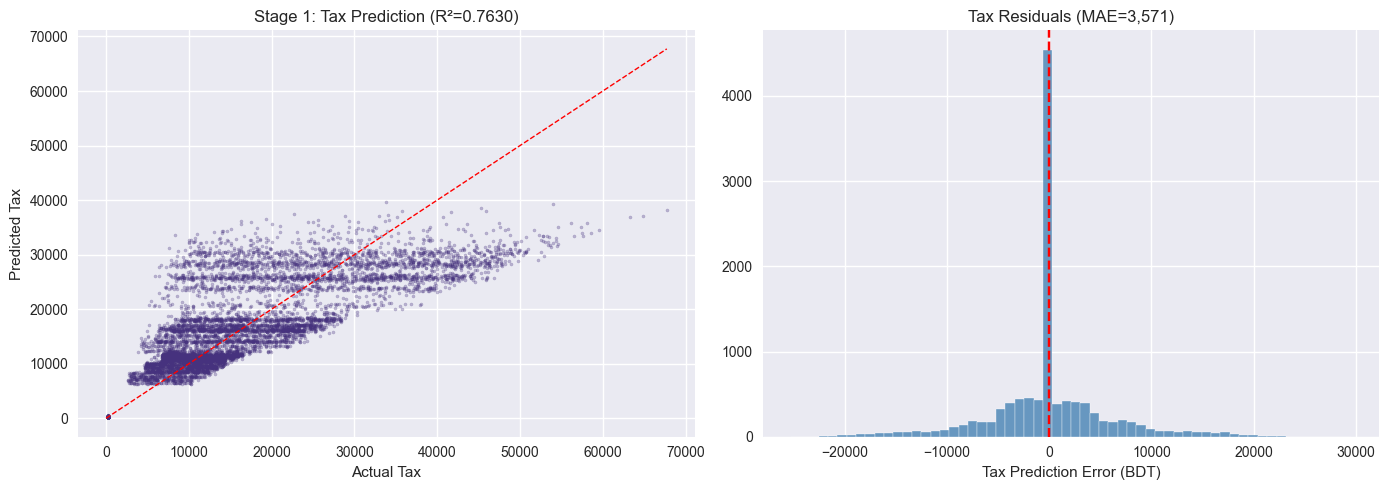

In [3]:
# ── 3. Stage 1: Train Tax Predictor (real features → Tax) ────────────────────
print("="*70)
print("STAGE 1: Predicting Tax & Surcharge from real features")
print("="*70)

t0 = time()
tax_model = CatBoostRegressor(
    iterations=3000, learning_rate=0.02, depth=8,
    l2_leaf_reg=3.0, random_seed=42,
    cat_features=cat_idx_clean,
    verbose=0, thread_count=-1,
    early_stopping_rounds=150,
    loss_function='RMSE',
)
tax_model.fit(X_train_clean, tax_train, eval_set=(X_test_clean, tax_test))

# Evaluate Tax predictor
tax_pred_train = tax_model.predict(X_train_clean)
tax_pred_test  = tax_model.predict(X_test_clean)

tax_r2_train = r2_score(tax_train, tax_pred_train)
tax_r2_test  = r2_score(tax_test, tax_pred_test)
tax_mae_test = mean_absolute_error(tax_test, tax_pred_test)

print(f"\nTax Predictor Performance:")
print(f"  Train R²: {tax_r2_train:.4f}")
print(f"  Test  R²: {tax_r2_test:.4f}")
print(f"  Test MAE: {tax_mae_test:,.0f} BDT")
print(f"  Test RMSE: {np.sqrt(mean_squared_error(tax_test, tax_pred_test)):,.0f} BDT")
print(f"  Trees: {tax_model.best_iteration_}  Time: {time()-t0:.0f}s")

# Visualize Tax prediction quality
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(tax_test.values, tax_pred_test, alpha=0.3, s=5)
lims = [0, max(tax_test.max(), tax_pred_test.max())]
axes[0].plot(lims, lims, 'r--', lw=1)
axes[0].set_xlabel('Actual Tax')
axes[0].set_ylabel('Predicted Tax')
axes[0].set_title(f'Stage 1: Tax Prediction (R²={tax_r2_test:.4f})')

residuals_tax = tax_test.values - tax_pred_test
axes[1].hist(residuals_tax, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', ls='--')
axes[1].set_xlabel('Tax Prediction Error (BDT)')
axes[1].set_title(f'Tax Residuals (MAE={tax_mae_test:,.0f})')
plt.tight_layout()
plt.show()

## 4. Stage 2 — Train Total Fare Model WITH Tax Feature

This model gets `Tax & Surcharge` as an input feature alongside all real features. During training it sees the **actual** Tax values. At evaluation time it will receive **predicted** Tax from Stage 1.

In [4]:
# ── 4. Stage 2: Train Total Fare model WITH Tax (leaky training) ─────────────
print("="*70)
print("STAGE 2: Training Total Fare model WITH Tax & Surcharge")
print("="*70)

# Model A: CatBoost with Tax (trained on ACTUAL Tax values)
t0 = time()
fare_model_with_tax = CatBoostRegressor(
    iterations=3000, learning_rate=0.02, depth=8,
    l2_leaf_reg=3.0, random_seed=42,
    cat_features=cat_idx_tax,
    verbose=0, thread_count=-1,
    early_stopping_rounds=150,
    loss_function='RMSE',
)
fare_model_with_tax.fit(X_train_tax, y_train, eval_set=(X_test_tax, y_test))

# Evaluate with ACTUAL Tax (upper bound — "cheating")
pred_actual_tax = fare_model_with_tax.predict(X_test_tax)
r2_actual = r2_score(y_test, pred_actual_tax)
mae_actual = mean_absolute_error(y_test, pred_actual_tax)

print(f"\nWith ACTUAL Tax (upper bound / cheating):")
print(f"  R² = {r2_actual:.4f}")
print(f"  MAE = {mae_actual:,.0f} BDT")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_test, pred_actual_tax)):,.0f} BDT")
print(f"  Trees: {fare_model_with_tax.best_iteration_}  Time: {time()-t0:.0f}s")

# Model B: Baseline — CatBoost WITHOUT Tax (honest model)
t0 = time()
fare_model_clean = CatBoostRegressor(
    iterations=3000, learning_rate=0.02, depth=8,
    l2_leaf_reg=3.0, random_seed=42,
    cat_features=cat_idx_clean,
    verbose=0, thread_count=-1,
    early_stopping_rounds=150,
    loss_function='RMSE',
)
fare_model_clean.fit(X_train_clean, y_train, eval_set=(X_test_clean, y_test))

pred_clean = fare_model_clean.predict(X_test_clean)
r2_clean = r2_score(y_test, pred_clean)
mae_clean = mean_absolute_error(y_test, pred_clean)

print(f"\nWithout Tax (baseline / honest):")
print(f"  R² = {r2_clean:.4f}")
print(f"  MAE = {mae_clean:,.0f} BDT")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_test, pred_clean)):,.0f} BDT")
print(f"  Trees: {fare_model_clean.best_iteration_}  Time: {time()-t0:.0f}s")

print(f"\n  Gap:  R² {r2_actual:.4f} vs {r2_clean:.4f} (Δ={r2_actual-r2_clean:+.4f})")
print(f"        MAE {mae_actual:,.0f} vs {mae_clean:,.0f} (Δ={mae_actual-mae_clean:+,.0f})")

STAGE 2: Training Total Fare model WITH Tax & Surcharge

With ACTUAL Tax (upper bound / cheating):
  R² = 0.9996
  MAE = 821 BDT
  RMSE = 1,595 BDT
  Trees: 2983  Time: 625s

Without Tax (baseline / honest):
  R² = 0.6887
  MAE = 27,873 BDT
  RMSE = 45,783 BDT
  Trees: 297  Time: 97s

  Gap:  R² 0.9996 vs 0.6887 (Δ=+0.3109)
        MAE 821 vs 27,873 (Δ=-27,052)


## 5. Two-Stage Evaluation Pipeline (Honest)

At prediction time, we **only** have real features. The pipeline:
1. Feed real features → Tax Predictor → get `predicted_tax`
2. Combine real features + `predicted_tax` → Total Fare Model → get `predicted_fare`

This is the **honest evaluation** — no data leakage.

In [5]:
# ── 5. Two-Stage Pipeline: Real features → Predict Tax → Predict Fare ────────
print("="*70)
print("TWO-STAGE PIPELINE EVALUATION (honest — only real features at input)")
print("="*70)

# Step 1: Predict Tax from real features on test set
tax_predicted = tax_model.predict(X_test_clean)

# Step 2: Build test features WITH predicted Tax (replace actual Tax)
X_test_2stage = X_test_clean.copy()
X_test_2stage[TAX_COL] = tax_predicted

# Reorder columns to match training feature order
X_test_2stage = X_test_2stage[X_train_tax.columns]

# Ensure category dtypes
for c in CAT_COLS:
    X_test_2stage[c] = X_test_2stage[c].astype(str).astype('category')

# Step 3: Predict Total Fare using the leaky-trained model + predicted Tax
pred_2stage = fare_model_with_tax.predict(X_test_2stage)

r2_2stage = r2_score(y_test, pred_2stage)
mae_2stage = mean_absolute_error(y_test, pred_2stage)
rmse_2stage = np.sqrt(mean_squared_error(y_test, pred_2stage))
medae_2stage = np.median(np.abs(y_test.values - pred_2stage))

print(f"\n  Two-Stage Pipeline (predicted Tax):")
print(f"    R²       = {r2_2stage:.4f}")
print(f"    MAE      = {mae_2stage:,.0f} BDT")
print(f"    RMSE     = {rmse_2stage:,.0f} BDT")
print(f"    Median AE = {medae_2stage:,.0f} BDT")

# ── Also do a stacking approach: predict Tax OOF on TRAINING set ─────────
# To avoid data leakage in the training pipeline itself, we use
# out-of-fold Tax predictions for training the fare model too
print("\n── Stacking variant: OOF Tax predictions for cleaner training ──")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
tax_oof = np.zeros(len(X_train_clean))

for fold_i, (tr_i, val_i) in enumerate(kf.split(X_train_clean)):
    tax_fold_model = CatBoostRegressor(
        iterations=2000, learning_rate=0.02, depth=8,
        l2_leaf_reg=3.0, random_seed=42,
        cat_features=cat_idx_clean,
        verbose=0, thread_count=-1,
        early_stopping_rounds=100,
        loss_function='RMSE',
    )
    tax_fold_model.fit(
        X_train_clean.iloc[tr_i], tax_train.iloc[tr_i],
        eval_set=(X_train_clean.iloc[val_i], tax_train.iloc[val_i])
    )
    tax_oof[val_i] = tax_fold_model.predict(X_train_clean.iloc[val_i])

oof_tax_r2 = r2_score(tax_train, tax_oof)
oof_tax_mae = mean_absolute_error(tax_train, tax_oof)
print(f"  OOF Tax prediction:  R²={oof_tax_r2:.4f}  MAE={oof_tax_mae:,.0f}")

# Train fare model on CLEAN features + OOF Tax predictions
X_train_stacked = X_train_clean.copy()
X_train_stacked[TAX_COL] = tax_oof
X_train_stacked = X_train_stacked[X_train_tax.columns]
for c in CAT_COLS:
    X_train_stacked[c] = X_train_stacked[c].astype(str).astype('category')

t0 = time()
fare_model_stacked = CatBoostRegressor(
    iterations=3000, learning_rate=0.02, depth=8,
    l2_leaf_reg=3.0, random_seed=42,
    cat_features=cat_idx_tax,
    verbose=0, thread_count=-1,
    early_stopping_rounds=150,
    loss_function='RMSE',
)
fare_model_stacked.fit(X_train_stacked, y_train, eval_set=(X_test_2stage, y_test))

pred_stacked = fare_model_stacked.predict(X_test_2stage)
r2_stacked = r2_score(y_test, pred_stacked)
mae_stacked = mean_absolute_error(y_test, pred_stacked)
rmse_stacked = np.sqrt(mean_squared_error(y_test, pred_stacked))

print(f"\n  Stacked Pipeline (OOF Tax in train, predicted Tax in test):")
print(f"    R²   = {r2_stacked:.4f}")
print(f"    MAE  = {mae_stacked:,.0f} BDT")
print(f"    RMSE = {rmse_stacked:,.0f} BDT")
print(f"    Time: {time()-t0:.0f}s")

TWO-STAGE PIPELINE EVALUATION (honest — only real features at input)

  Two-Stage Pipeline (predicted Tax):
    R²       = 0.6880
    MAE      = 27,900 BDT
    RMSE     = 45,837 BDT
    Median AE = 13,330 BDT

── Stacking variant: OOF Tax predictions for cleaner training ──
  OOF Tax prediction:  R²=0.7605  MAE=3,552

  Stacked Pipeline (OOF Tax in train, predicted Tax in test):
    R²   = 0.6879
    MAE  = 27,921 BDT
    RMSE = 45,844 BDT
    Time: 111s


## 6. Comprehensive Comparison & Visualization

Compare all approaches:
| Approach | Training Features | Evaluation Features |
|---|---|---|
| **A — Cheating** | real + actual Tax | real + actual Tax |
| **B — Two-Stage** | real + actual Tax (train) | real + predicted Tax (test) |
| **C — Stacked** | real + OOF Tax (train) | real + predicted Tax (test) |
| **D — Baseline** | real only | real only |

FINAL COMPARISON TABLE
                     Approach   R²       MAE      RMSE  MAE Improvement vs Baseline
    A — Cheating (actual Tax) 1.00    821.21  1,594.84                        97.05
B — Two-Stage (predicted Tax) 0.69 27,899.52 45,837.23                        -0.09
  C — Stacked (OOF Tax train) 0.69 27,920.71 45,844.14                        -0.17
        D — Baseline (no Tax) 0.69 27,873.27 45,782.64                         0.00


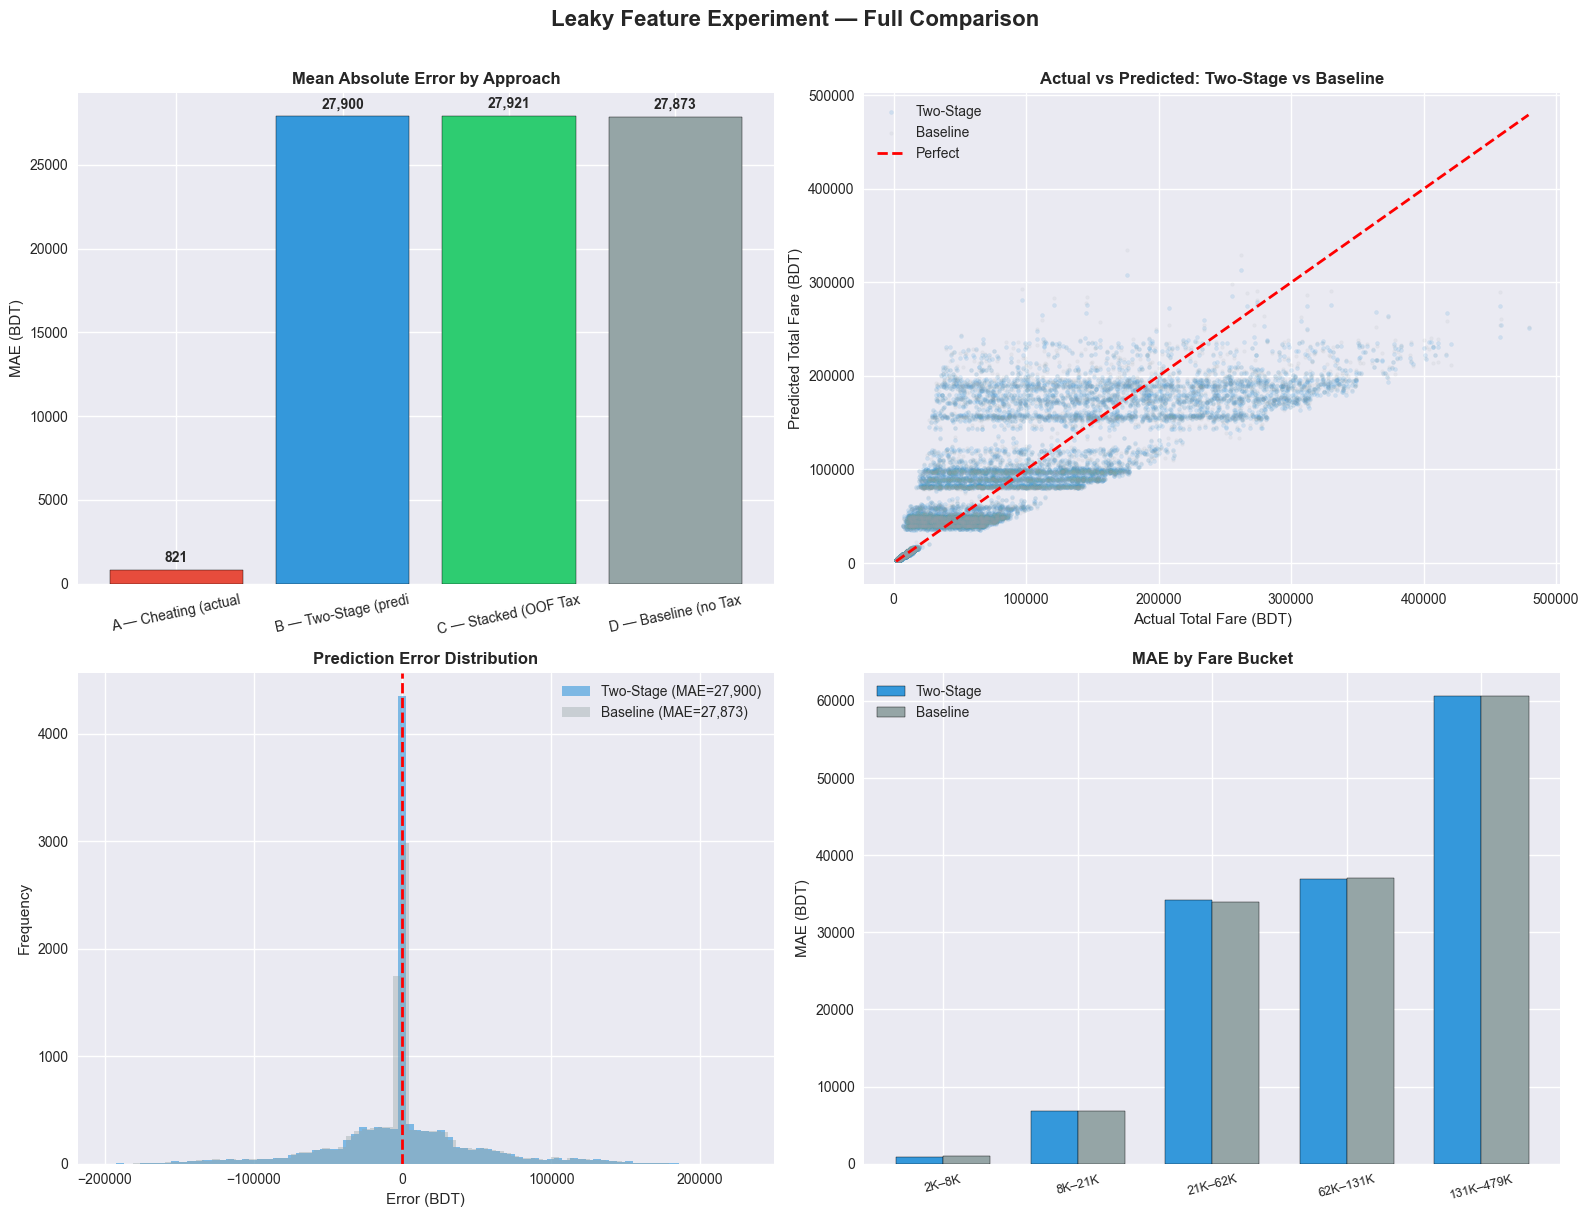


EXECUTIVE SUMMARY
  Baseline  MAE (no Tax)        :     27,873 BDT
  Two-Stage MAE (predicted Tax)  :     27,900 BDT
  Stacked   MAE (OOF Tax)        :     27,921 BDT
  Cheating  MAE (actual Tax)     :        821 BDT

  Two-Stage improvement over baseline: -0.09%
  Cheating ceiling (upper bound)     : +97.05%

  Tax prediction quality  : R²=0.7630, MAE=3,571
  → Tax prediction error propagates into Total Fare prediction


In [6]:
# ── 6. Comprehensive Comparison ───────────────────────────────────────────────

# --- Predict for cheating model (actual Tax on test) ---
pred_cheat = fare_model_with_tax.predict(X_test_tax)
r2_cheat  = r2_score(y_test, pred_cheat)
mae_cheat = mean_absolute_error(y_test, pred_cheat)
rmse_cheat = np.sqrt(mean_squared_error(y_test, pred_cheat))

# --- Predict for baseline model (no Tax) ---
pred_base = fare_model_clean.predict(X_test_clean)
r2_base  = r2_score(y_test, pred_base)
mae_base = mean_absolute_error(y_test, pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, pred_base))

# Summary table
results = pd.DataFrame({
    'Approach': [
        'A — Cheating (actual Tax)',
        'B — Two-Stage (predicted Tax)',
        'C — Stacked (OOF Tax train)',
        'D — Baseline (no Tax)',
    ],
    'R²':   [r2_cheat, r2_2stage, r2_stacked, r2_base],
    'MAE':  [mae_cheat, mae_2stage, mae_stacked, mae_base],
    'RMSE': [rmse_cheat, rmse_2stage, rmse_stacked, rmse_base],
})
results['MAE Improvement vs Baseline'] = (
    (results['MAE'].iloc[-1] - results['MAE']) / results['MAE'].iloc[-1] * 100
)
print("="*80)
print("FINAL COMPARISON TABLE")
print("="*80)
print(results.to_string(index=False, float_format='{:,.2f}'.format))

# ── Visualizations ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- 6a. Bar: MAE comparison ---
ax = axes[0, 0]
colors = ['#e74c3c', '#3498db', '#2ecc71', '#95a5a6']
bars = ax.bar(results['Approach'].str.slice(0, 20), results['MAE'], color=colors, edgecolor='black')
for bar, val in zip(bars, results['MAE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{val:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_ylabel('MAE (BDT)')
ax.set_title('Mean Absolute Error by Approach', fontweight='bold')
ax.tick_params(axis='x', rotation=12)

# --- 6b. Actual vs Predicted for Two-Stage ---
ax = axes[0, 1]
ax.scatter(y_test, pred_2stage, alpha=0.15, s=8, color='#3498db', label='Two-Stage')
ax.scatter(y_test, pred_base, alpha=0.1, s=6, color='#95a5a6', label='Baseline')
mi, ma = y_test.min(), y_test.max()
ax.plot([mi, ma], [mi, ma], 'r--', lw=2, label='Perfect')
ax.set_xlabel('Actual Total Fare (BDT)')
ax.set_ylabel('Predicted Total Fare (BDT)')
ax.set_title('Actual vs Predicted: Two-Stage vs Baseline', fontweight='bold')
ax.legend()

# --- 6c. Error distribution ---
ax = axes[1, 0]
err_2stage = y_test.values - pred_2stage
err_base   = y_test.values - pred_base
ax.hist(err_2stage, bins=80, alpha=0.6, color='#3498db', label=f'Two-Stage (MAE={mae_2stage:,.0f})')
ax.hist(err_base, bins=80, alpha=0.4, color='#95a5a6', label=f'Baseline (MAE={mae_base:,.0f})')
ax.axvline(0, color='red', ls='--', lw=2)
ax.set_xlabel('Error (BDT)')
ax.set_ylabel('Frequency')
ax.set_title('Prediction Error Distribution', fontweight='bold')
ax.legend()

# --- 6d. MAE by fare bucket ---
ax = axes[1, 1]
buckets = pd.qcut(y_test, q=5, duplicates='drop')
bucket_labels = sorted(buckets.unique())

mae_by_bucket_2s = []
mae_by_bucket_bl = []
labels = []
for bk in bucket_labels:
    mask = buckets == bk
    mae_by_bucket_2s.append(mean_absolute_error(y_test[mask], pred_2stage[mask]))
    mae_by_bucket_bl.append(mean_absolute_error(y_test[mask], pred_base[mask]))
    labels.append(f'{bk.left/1000:.0f}K–{bk.right/1000:.0f}K')

x_pos = np.arange(len(labels))
w = 0.35
ax.bar(x_pos - w/2, mae_by_bucket_2s, w, color='#3498db', label='Two-Stage', edgecolor='black')
ax.bar(x_pos + w/2, mae_by_bucket_bl, w, color='#95a5a6', label='Baseline', edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=15, fontsize=9)
ax.set_ylabel('MAE (BDT)')
ax.set_title('MAE by Fare Bucket', fontweight='bold')
ax.legend()

plt.suptitle('Leaky Feature Experiment — Full Comparison', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Executive summary ─────────────────────────────────────────────────────────
best_approach = results.loc[results['MAE'].idxmin()]
improvement = (mae_base - mae_2stage) / mae_base * 100
print(f"\n{'='*80}")
print(f"EXECUTIVE SUMMARY")
print(f"{'='*80}")
print(f"  Baseline  MAE (no Tax)        : {mae_base:>10,.0f} BDT")
print(f"  Two-Stage MAE (predicted Tax)  : {mae_2stage:>10,.0f} BDT")
print(f"  Stacked   MAE (OOF Tax)        : {mae_stacked:>10,.0f} BDT")
print(f"  Cheating  MAE (actual Tax)     : {mae_cheat:>10,.0f} BDT")
print(f"\n  Two-Stage improvement over baseline: {improvement:+.2f}%")
print(f"  Cheating ceiling (upper bound)     : {(mae_base - mae_cheat) / mae_base * 100:+.2f}%")
print(f"\n  Tax prediction quality  : R²={r2_score(tax_test, tax_predicted):.4f}, MAE={mean_absolute_error(tax_test, tax_predicted):,.0f}")
print(f"  → Tax prediction error propagates into Total Fare prediction")
print(f"{'='*80}")